In [140]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn

In [141]:
x=torch.arange(0,1,0.02)

In [142]:
x.shape

torch.Size([50])

In [143]:
x.dtype


torch.float32

In [144]:
w=0.9
c=4
y=x**2

In [145]:
y

tensor([0.0000e+00, 4.0000e-04, 1.6000e-03, 3.6000e-03, 6.4000e-03, 1.0000e-02,
        1.4400e-02, 1.9600e-02, 2.5600e-02, 3.2400e-02, 4.0000e-02, 4.8400e-02,
        5.7600e-02, 6.7600e-02, 7.8400e-02, 9.0000e-02, 1.0240e-01, 1.1560e-01,
        1.2960e-01, 1.4440e-01, 1.6000e-01, 1.7640e-01, 1.9360e-01, 2.1160e-01,
        2.3040e-01, 2.5000e-01, 2.7040e-01, 2.9160e-01, 3.1360e-01, 3.3640e-01,
        3.6000e-01, 3.8440e-01, 4.0960e-01, 4.3560e-01, 4.6240e-01, 4.9000e-01,
        5.1840e-01, 5.4760e-01, 5.7760e-01, 6.0840e-01, 6.4000e-01, 6.7240e-01,
        7.0560e-01, 7.3960e-01, 7.7440e-01, 8.1000e-01, 8.4640e-01, 8.8360e-01,
        9.2160e-01, 9.6040e-01])

In [146]:
y.dtype

torch.float32

In [147]:
device='mps' if torch.backends.mps.is_available() else 'cpu'

In [148]:
x=x.to(device)
y=y.to(device)

In [149]:
model=nn.Sequential(
                    nn.Linear(in_features=1,out_features=5),
                    nn.ReLU(),
                    nn.Linear(in_features=5,out_features=1)
).to(device)

class expo(nn.Module):
    def __init__(self):
        super().__init__()
        self

In [150]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.9928],
                      [-0.1942],
                      [ 0.5236],
                      [ 0.4379],
                      [-0.1374]], device='mps:0')),
             ('0.bias',
              tensor([-0.1668, -0.8049,  0.1662,  0.7862,  0.3149], device='mps:0')),
             ('2.weight',
              tensor([[ 0.3522, -0.2123,  0.1755, -0.3045, -0.1538]], device='mps:0')),
             ('2.bias', tensor([0.4316], device='mps:0'))])

In [151]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [152]:
epochs=500
x_train=x[:int(0.8*len(x))]
x_test=x[int(0.8*len(x)):]
y_train=y[:int(0.8*len(x))]
y_test=y[int(0.8*len(x)):]
l=[]
print(x_train.shape,x_train.dtype)
from tqdm.auto import tqdm
for epoch in tqdm(range(epochs)):
    model.train()
    y_pred=model(x_train.unsqueeze(dim=1))
    l.append(loss.to('cpu').detach().numpy())
    loss=loss_fn(y_pred,y_train.unsqueeze(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if(epoch%10==0):
        print(loss)
   


torch.Size([40]) torch.float32


  0%|          | 0/500 [00:00<?, ?it/s]

tensor(0.1603, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1585, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1566, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1548, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1529, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1510, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1491, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1471, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1451, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1431, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1411, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1390, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1369, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1347, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1325, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1302, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1279, device='mps:0', grad_fn=<MeanBackward0>)
tensor(0.1256, device='mps:0', grad_fn=<MeanBack

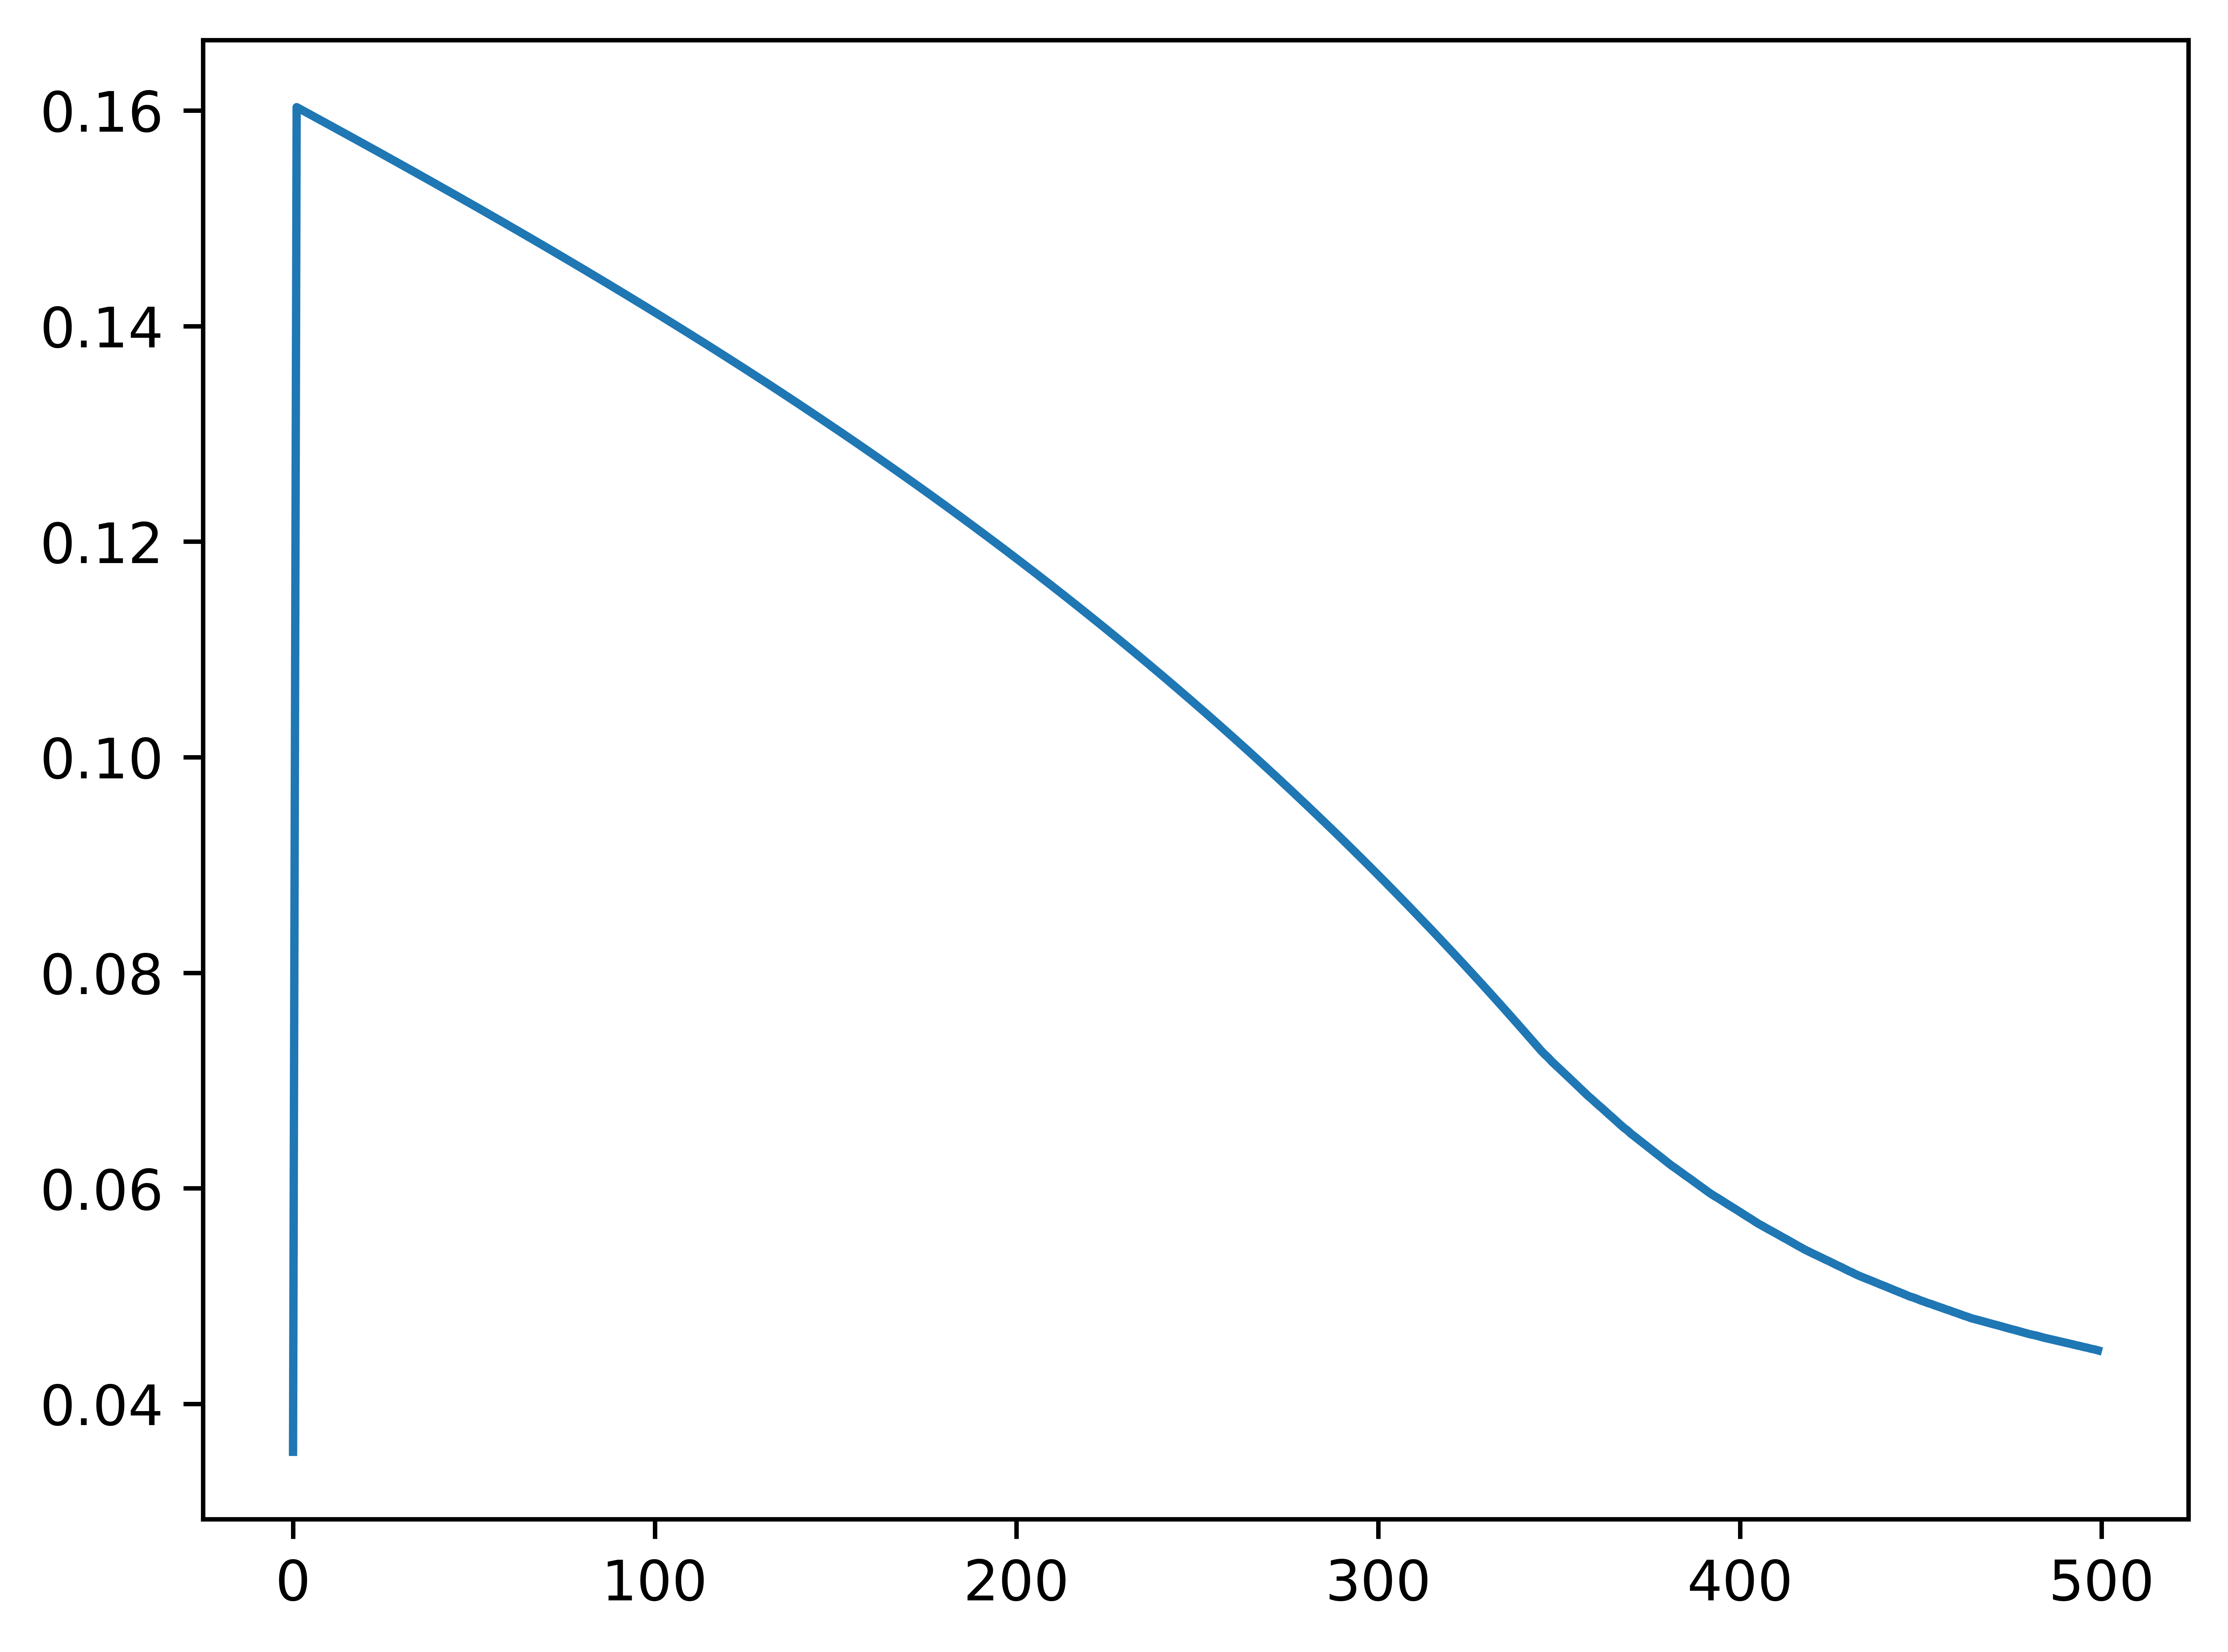

In [153]:
plt.figure(dpi=1000)
plt.plot(l)

In [154]:

with torch.inference_mode():
    test=model(x_test.unsqueeze(dim=1))
print(test)
print(y_test)

tensor([[0.4510],
        [0.4638],
        [0.4766],
        [0.4894],
        [0.5022],
        [0.5150],
        [0.5278],
        [0.5406],
        [0.5534],
        [0.5662]], device='mps:0')
tensor([0.6400, 0.6724, 0.7056, 0.7396, 0.7744, 0.8100, 0.8464, 0.8836, 0.9216,
        0.9604], device='mps:0')


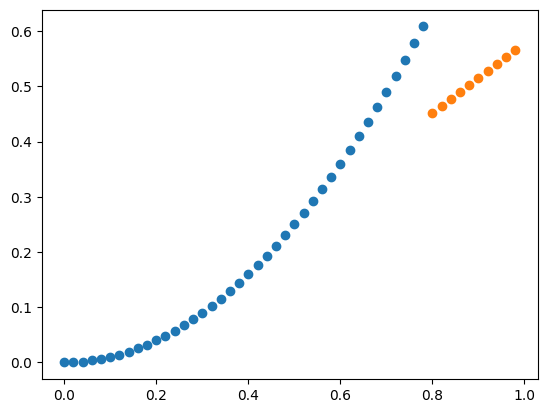

In [155]:
plt.scatter(x_train.to('cpu').detach().numpy(),y_train.to('cpu').detach().numpy())
plt.scatter(x_test.to('cpu').detach().numpy(),test.to('cpu').detach().numpy())